# Trabajo práctico 4: Aprendizaje No Supervisado

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys 
sys.path.append(os.path.abspath("./src"))
sys.path.append(os.path.abspath("./data"))

import utils as utls 
import pca as pca
import autoencoder as ae
import clustering as clust
from collections import Counter

## 1. Inspección de Datos

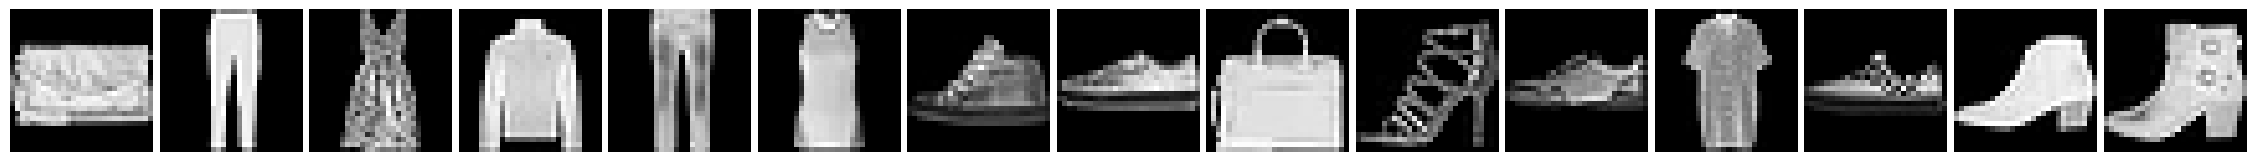

array([ 1815, 16016, 20600,  8113,  2247, 20934, 24555,  2423, 11934,
       22014, 17917,  1461, 23851, 15088,  2459], dtype=int32)

In [3]:
df = pd.read_csv("./data/fashion_mnist_subset.csv")

utls.plot_images(df, 15)
#Ver de hacer las fotos mas grandes


In [ ]:
print(df.shape)
print(df.head())

# Separar features y etiquetas
X = df.iloc[:, :-1].values  # píxeles
y = df.iloc[:, -1].values   # etiquetas

(25000, 785)
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0   0.0039   0.0000   
1      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
2      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
3      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0627   
4      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   

   pixel_8  pixel_9  ...  pixel_775  pixel_776  pixel_777  pixel_778  \
0   0.0196   0.0902  ...     0.1647     0.0000     0.0000     0.0000   
1   0.0000   0.0000  ...     0.0000     0.0000     0.0000     0.0000   
2   0.0000   0.0000  ...     0.4235     0.2157     0.0000     0.0000   
3   0.2078   0.0000  ...     0.0549     0.0000     0.1529     0.3843   
4   0.0000   0.0000  ...     0.0000     0.0000     0.0078     0.0000   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  label  
0     0.0000        0.0  

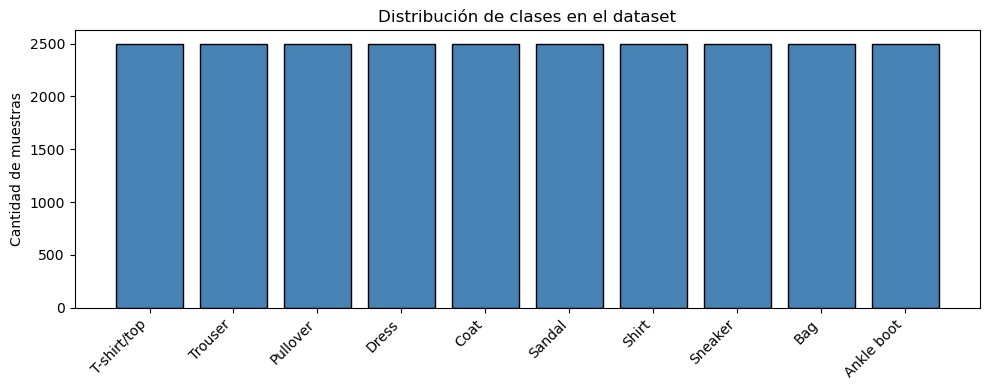

In [5]:
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

class_counts = Counter(y)
classes, counts = zip(*sorted(class_counts.items()))
labels = [class_names[c] for c in classes]

utls.barplot(labels, counts)

El dataset esta completamente balanceado, todas las clases tienen 2500 muestras. Esto significa que no hay riesgo de sesgos en el entrenamiento hacia ninguna clase en particular.

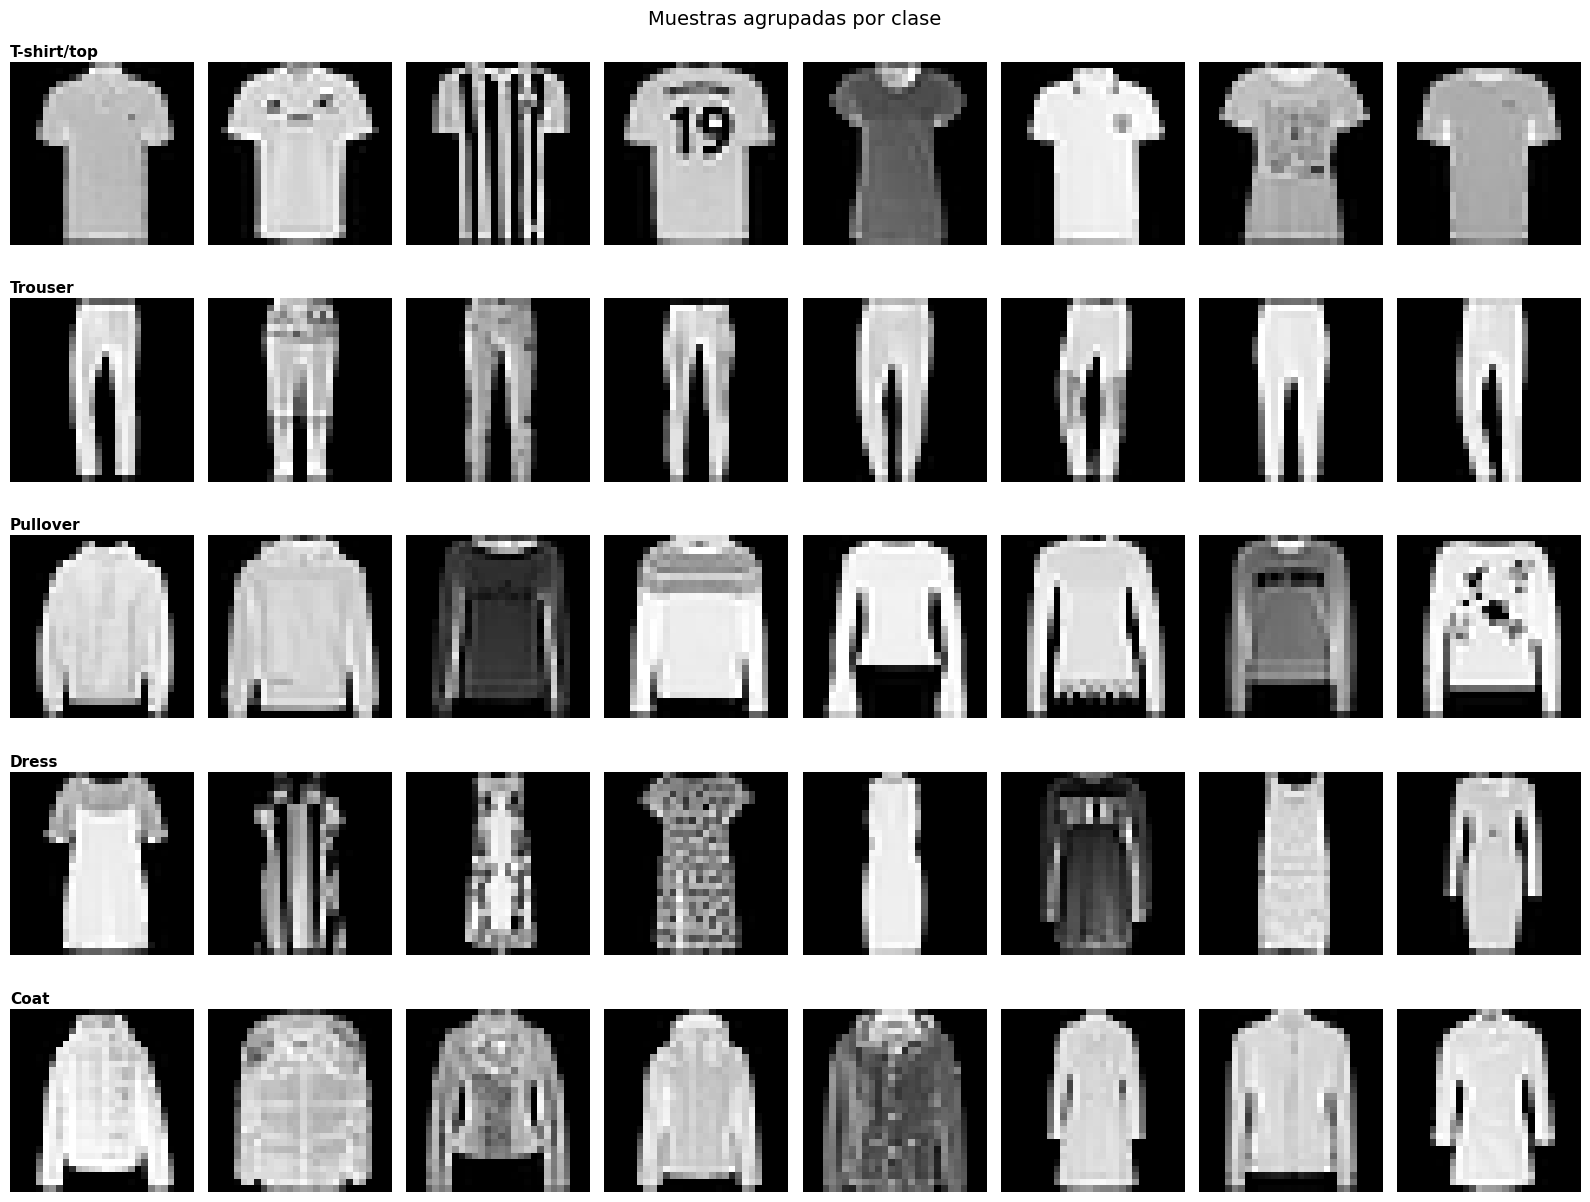

In [ ]:
utls.plot_samples_by_class(X, y, class_names, n_samples=8,
                      classes_to_show=[0, 1, 2, 3, 4])

Se puede ver que dentro de las clases propias, la muestras varian mucho entre ellas, ya sea en color, estampado, largo o textura.

Tambien algunas clases pueden confundirse entre si por similitudes en los diseños, como vestidos, tapados y pullovers. Esto significa que los modelos de aprendizaje no supervisado podrian llegar a confundir estas clases.


### Split de Train/Test

In [7]:
# Split estratificado: cada subconjunto debe mantener la misma proporcion de clases que el dataset original

X_train, X_test, y_train, y_test = utls.stratified_split(X, y, test_size=0.2)



## 2. Reduccion de Dimensionalidad

In [8]:
# Estandarizar
X_train_std, X_test_std, med, des = utls.standarization(X_train, X_test)

In [9]:

# Aprender PCA sobre train para ver varianza
eigenvalues, eigenvectors = pca.pca_fit(X_train_std)

varianza_explicada = eigenvalues / np.sum(eigenvalues)
varianza_acumulada = np.cumsum(varianza_explicada)

# Elegir K componentes que expliquen el 90%
K = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes para 90% de varianza: {K}")

# Transformar train y test con K componentes
eigenvectors_K = eigenvectors[:, :K]  
X_train_pca = pca.pca_transform(X_train_std, eigenvectors_K)
X_test_pca  = pca.pca_transform(X_test_std,  eigenvectors_K)


Componentes para 90% de varianza: 135


Text(0, 0.5, 'Varianza explicada acumulada')

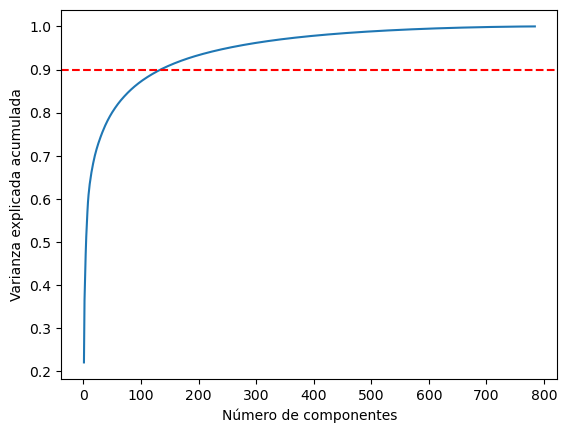

In [10]:
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada)
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')

Gracias a la reduccion de PCA, se puede identificar que 135 componentes son suficientes para capturar el 90% de la varianza de los datos, y por ende se puede descartar el 10% restante. Esto es porque al realizar la reconstruccion de los datos con estas 135 componentes de mayor varianza, se conserva el 90% de la informacion del dataset. 

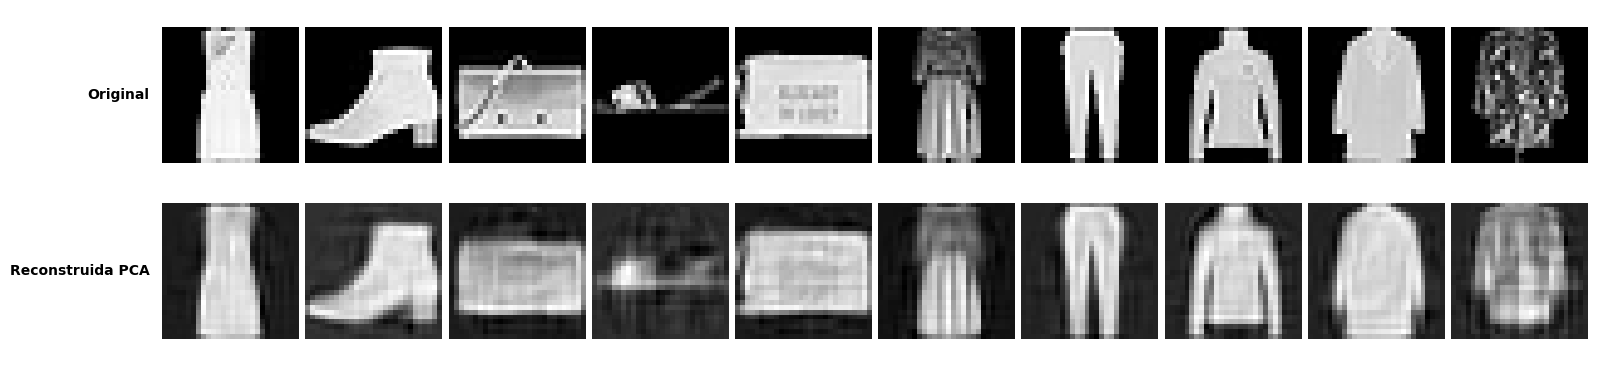

array([10612, 16579, 13486, 12442, 18961,  7310,  8510, 14240,   694,
        6741], dtype=int32)

In [11]:

X_reconstruido_std = X_train_pca @ eigenvectors_K.T 
X_reconstruido = X_reconstruido_std * des + med    # des-estandarizar

# 2b - comparación originales vs reconstruidas
utls.plot_images([X_train, X_reconstruido], n_images=10,
            row_labels=["Original", "Reconstruida PCA"])


#### Entrenamiento de AutoEncoder con PyTorch

In [12]:
from torch.utils.data import DataLoader, TensorDataset


LATENT_DIM = 135  # igual que PCA
EPOCHS = 50
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datos como tensores
X_train_t = torch.FloatTensor(X_train_std).to(device)  
X_val_t   = torch.FloatTensor(X_test_std).to(device)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

model = ae.Autoencoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_loss = []
    for (x_batch,) in train_loader:
        optimizer.zero_grad()
        x_hat = model(x_batch)
        loss = criterion(x_hat, x_batch)
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
    
    # Validación
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), X_val_t).item()
    
    train_losses.append(sum(batch_loss) / len(batch_loss))
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    X_train_ae = model.encoder(torch.FloatTensor(X_train_std).to(device)).cpu().numpy()
    X_test_ae  = model.encoder(torch.FloatTensor(X_test_std).to(device)).cpu().numpy()

Epoch 10/50 | Train: 0.1710 | Val: 0.1737
Epoch 20/50 | Train: 0.1313 | Val: 0.1424
Epoch 30/50 | Train: 0.1163 | Val: 0.1373
Epoch 40/50 | Train: 0.1019 | Val: 0.1267
Epoch 50/50 | Train: 0.1058 | Val: 0.1176


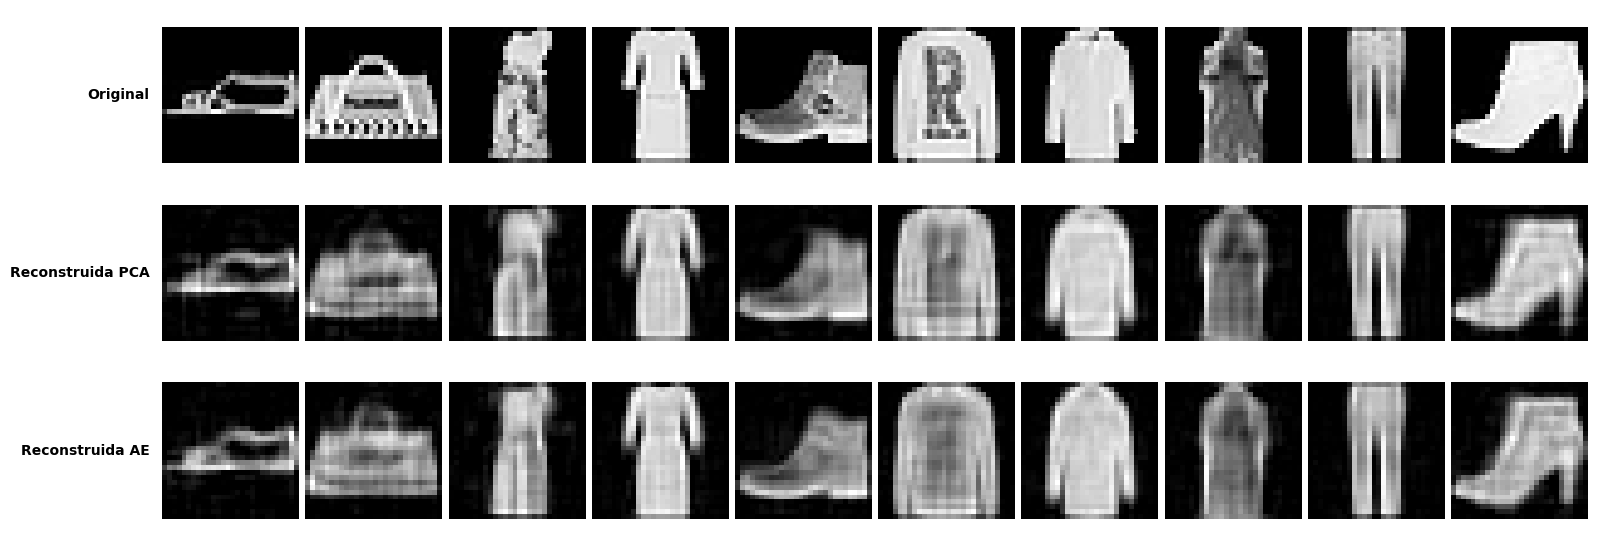

array([8, 9, 4, 0, 2, 3, 6, 1, 5, 7], dtype=int32)

In [13]:
idx = np.random.choice(len(X_test), 10, replace=False)

originales_vis = X_test[idx].astype(np.float32)

# Reconstrucción AE: pasar X_test_std por el modelo completo
model.eval()
with torch.no_grad():
    recon_ae_std = model(torch.FloatTensor(X_test_std[idx]).to(device)).cpu().numpy()
recon_ae = np.clip(recon_ae_std * des + med, 0, 255)

# Reconstrucción PCA
X_test_reconstruido_std = X_test_pca @ eigenvectors_K.T
recon_pca = np.clip(X_test_reconstruido_std[idx] * des + med, 0, 255)

utls.plot_images([originales_vis, recon_pca, recon_ae], n_images=10,
                 row_labels=["Original", "Reconstruida PCA", "Reconstruida AE"])

## 3. Clustering

Algoritmo K-Means

In [14]:
_, X_cluster, _, y_cluster = utls.stratified_split(X_train_pca, y_train, test_size=3000/len(X_train_pca))

resultados_kmeans = {}
for K in range(5, 16):
    labels, centroids, inertia = clust.kmeans(X_cluster, K=K)
    resultados_kmeans[K] = {"labels": labels, "centroids": centroids, "inertia": inertia}
    print(f"K={K} | Inertia: {inertia:.2f}")

K=5 | Inertia: 1301606.96
K=6 | Inertia: 1230016.29
K=7 | Inertia: 1157933.05
K=8 | Inertia: 1118684.23
K=9 | Inertia: 1083482.96
K=10 | Inertia: 1052177.39
K=11 | Inertia: 1022854.64
K=12 | Inertia: 1000733.62
K=13 | Inertia: 980963.97
K=14 | Inertia: 961478.28
K=15 | Inertia: 945800.96


Algortimo GMM

In [15]:
resultados_gmm = {}
for K in range(5, 16):
    labels, mu, sigma, pi, ll = clust.gmm(X_cluster, K=K)
    resultados_gmm[K] = {"labels": labels, "mu": mu, "ll": ll}
    print(f"K={K} | Log-likelihood: {ll:.2f}")

K=5 | Log-likelihood: -612142.04
K=6 | Log-likelihood: -607022.45
K=7 | Log-likelihood: -604703.28
K=8 | Log-likelihood: -602353.51
K=9 | Log-likelihood: -600006.34
K=10 | Log-likelihood: -597701.98
K=11 | Log-likelihood: -595623.72
K=12 | Log-likelihood: -593815.09
K=13 | Log-likelihood: -594379.30
K=14 | Log-likelihood: -590894.34
K=15 | Log-likelihood: -590777.04


### Analisis de K 

K= 5 | Silhouette K-Means: 0.1489 | Silhouette GMM: 0.0415
K= 6 | Silhouette K-Means: 0.1608 | Silhouette GMM: 0.0396
K= 7 | Silhouette K-Means: 0.1627 | Silhouette GMM: 0.0523
K= 8 | Silhouette K-Means: 0.1541 | Silhouette GMM: 0.0680
K= 9 | Silhouette K-Means: 0.1561 | Silhouette GMM: 0.0603
K=10 | Silhouette K-Means: 0.1565 | Silhouette GMM: 0.0328
K=11 | Silhouette K-Means: 0.1507 | Silhouette GMM: 0.0242
K=12 | Silhouette K-Means: 0.1354 | Silhouette GMM: 0.0179
K=13 | Silhouette K-Means: 0.1435 | Silhouette GMM: 0.0300
K=14 | Silhouette K-Means: 0.1412 | Silhouette GMM: 0.0144
K=15 | Silhouette K-Means: 0.1437 | Silhouette GMM: 0.0404


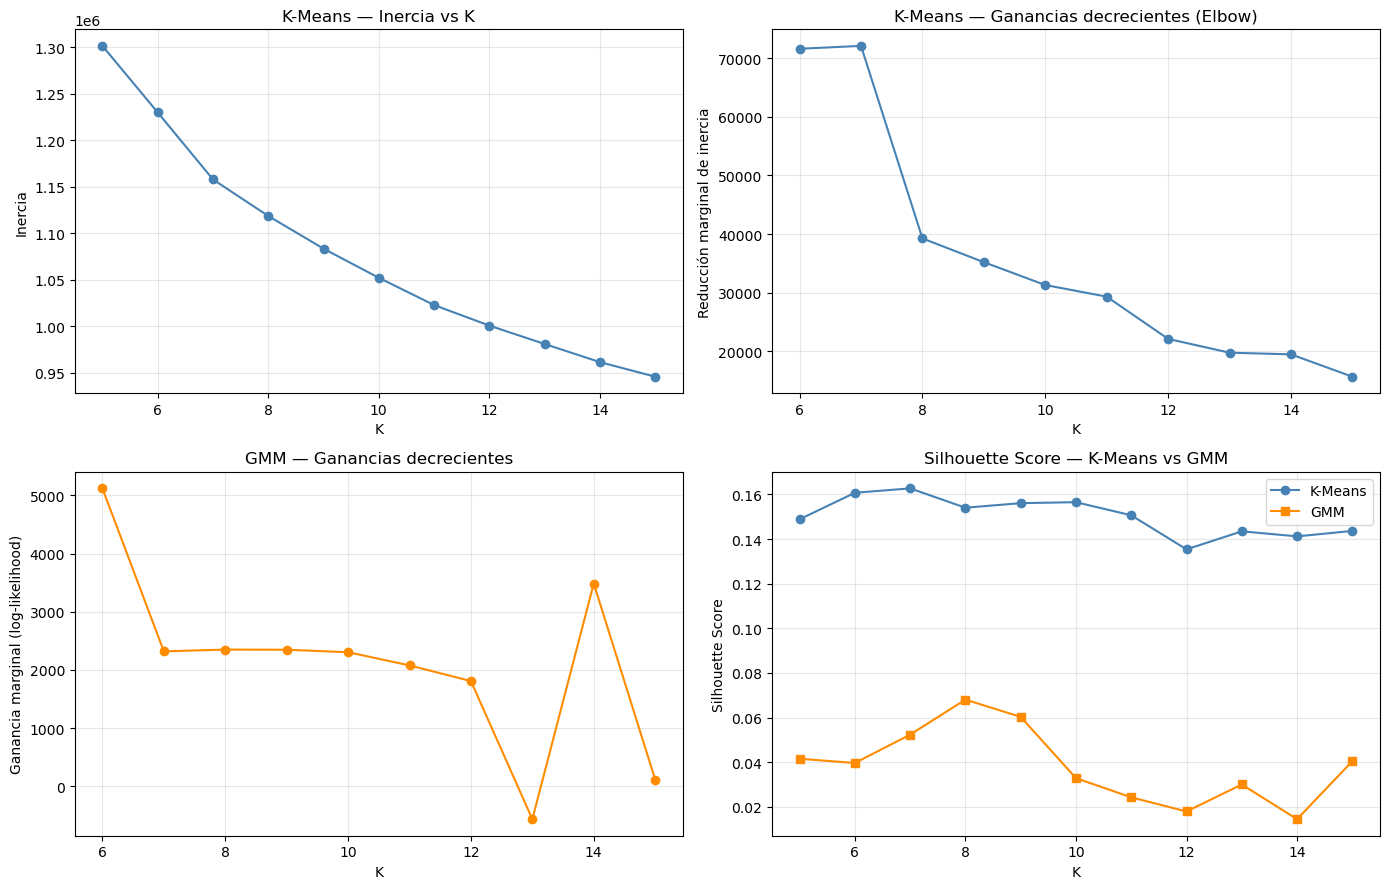

In [16]:
# K-Means: Elbow (inercia) 
ks = list(resultados_kmeans.keys())
inercias = [resultados_kmeans[k]["inertia"] for k in ks]
ganancia_marginal_kmeans = [inercias[i-1] - inercias[i] for i in range(1, len(inercias))]  # reducción

# GMM: Ganancias decrecientes (log-likelihood) 
ks_gmm = list(resultados_gmm.keys())
lls = [resultados_gmm[k]["ll"] for k in ks_gmm]
ganancia_marginal_gmm = [lls[i] - lls[i-1] for i in range(1, len(lls))]

# Silhouette: K-Means y GMM 
silhouette_kmeans = {}
silhouette_gmm    = {}
for K in range(5, 16):
    silhouette_kmeans[K] = clust.silhouette_score(X_cluster, resultados_kmeans[K]["labels"])
    silhouette_gmm[K]    = clust.silhouette_score(X_cluster, resultados_gmm[K]["labels"])
    print(f"K={K:2d} | Silhouette K-Means: {silhouette_kmeans[K]:.4f} | Silhouette GMM: {silhouette_gmm[K]:.4f}")

# ── Plots 
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Elbow K-Means
axes[0, 0].plot(ks, inercias, marker='o', color='steelblue')
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inercia")
axes[0, 0].set_title("K-Means — Inercia vs K")
axes[0, 0].grid(alpha=0.3)

# 2) Ganancia marginal K-Means
axes[0, 1].plot(ks[1:], ganancia_marginal_kmeans, marker='o', color='steelblue')
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Reducción marginal de inercia")
axes[0, 1].set_title("K-Means — Ganancias decrecientes (Elbow)")
axes[0, 1].grid(alpha=0.3)

# 3) Ganancia marginal GMM
axes[1, 0].plot(ks_gmm[1:], ganancia_marginal_gmm, marker='o', color='darkorange')
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Ganancia marginal (log-likelihood)")
axes[1, 0].set_title("GMM — Ganancias decrecientes")
axes[1, 0].grid(alpha=0.3)

# 4) Silhouette K-Means vs GMM
axes[1, 1].plot(list(silhouette_kmeans.keys()), list(silhouette_kmeans.values()),
                marker='o', label='K-Means', color='steelblue')
axes[1, 1].plot(list(silhouette_gmm.keys()), list(silhouette_gmm.values()),
                marker='s', label='GMM', color='darkorange')
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Silhouette Score")
axes[1, 1].set_title("Silhouette Score — K-Means vs GMM")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Visualización t-SNE de los Clusters


In [22]:
import tsne as tsne_mod

# Mejor K del análisis anterior
BEST_K = 8
labels_best = resultados_kmeans[BEST_K]["labels"]

# t-SNE sobre el espacio latente del PCA
# X_cluster: submuestra de 3000 puntos ya en espacio PCA
Y_tsne = tsne_mod.tsne(
    X_cluster,
    n_components=2,
    perplexity=30,
    n_iter=500,
    lr=200.0,
    early_exaggeration=4.0,
    exaggeration_iter=100,
    random_seed=42,
    verbose=True
)


[t-SNE] n=3000, d=135, perplexity=30, n_iter=500, lr=200.0
[t-SNE] Iter  100/500 | KL divergence: 2.6973
[t-SNE] Iter  200/500 | KL divergence: 1.7391
[t-SNE] Iter  300/500 | KL divergence: 1.5500
[t-SNE] Iter  400/500 | KL divergence: 1.4532
[t-SNE] Iter  500/500 | KL divergence: 1.3909


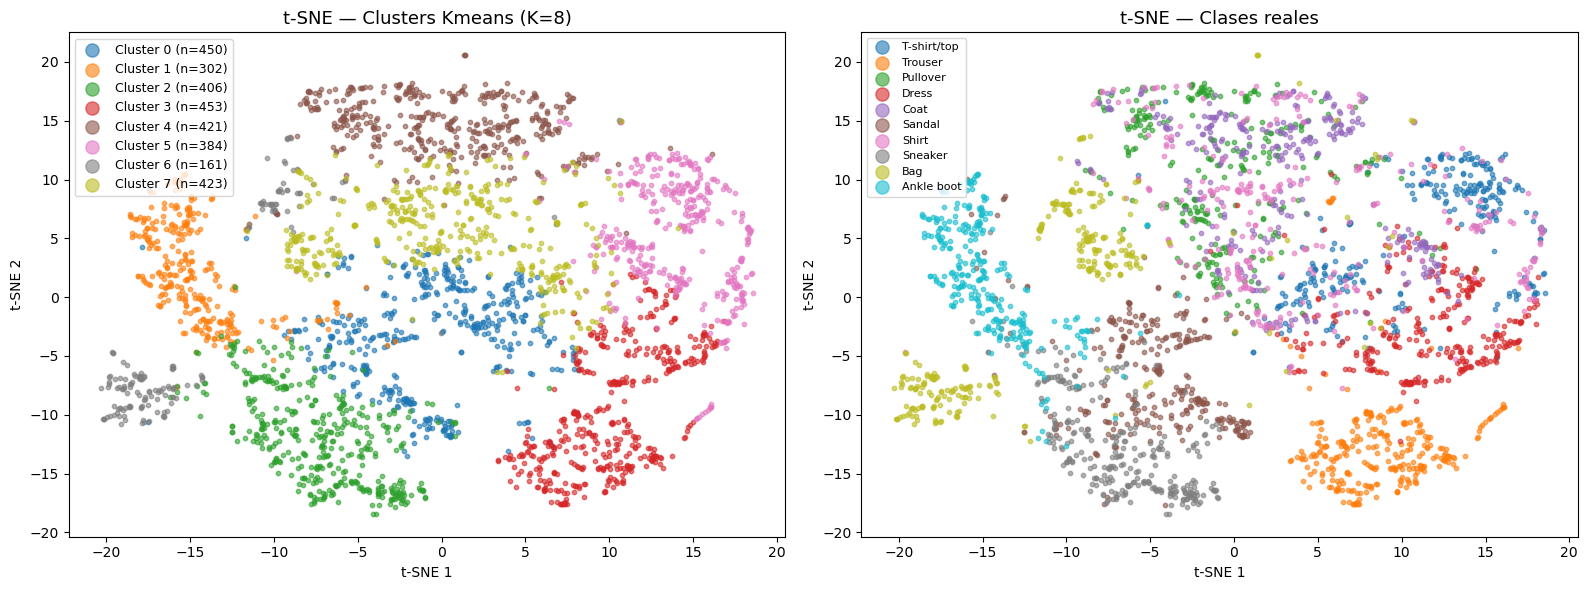

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap_clusters = plt.cm.tab10
cmap_classes  = plt.cm.tab10

#Color por cluster asignado
ax = axes[0]
for k in range(BEST_K):
    mask = labels_best == k
    ax.scatter(Y_tsne[mask, 0], Y_tsne[mask, 1],
               c=[cmap_clusters(k / BEST_K)],
               label=f"Cluster {k} (n={mask.sum()})",
               s=10, alpha=0.6)
ax.set_title(f"t-SNE — Clusters Kmeans (K={BEST_K})", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3, fontsize=9)

# Color por clase real
ax = axes[1]
n_classes = len(class_names)
for c in sorted(class_names.keys()):
    mask = y_cluster == c
    ax.scatter(Y_tsne[mask, 0], Y_tsne[mask, 1],
               c=[cmap_classes(c / n_classes)],
               label=class_names[c],
               s=10, alpha=0.6)
ax.set_title("t-SNE — Clases reales", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3, fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [24]:
# Tabla de distribución de clases reales por cluster
rows = []
for k in range(BEST_K):
    mask = labels_best == k
    row = {"Cluster": k, "N muestras": int(mask.sum())}
    for c in sorted(class_names.keys()):
        row[class_names[c]] = int((y_cluster[mask] == c).sum())
    rows.append(row)

df_dist = pd.DataFrame(rows).set_index("Cluster")
print("Distribución de clases reales por cluster:")
print(df_dist.to_string())

# Homogeneidad: clase dominante y su proporción dentro del cluster
print("\nClase dominante y homogeneidad por cluster:")
for k in range(BEST_K):
    mask = labels_best == k
    counts_k = np.array([(y_cluster[mask] == c).sum() for c in sorted(class_names.keys())])
    dom_idx   = np.argmax(counts_k)
    dom_class = class_names[dom_idx]
    homog     = counts_k[dom_idx] / mask.sum()
    print(f"  Cluster {k}: N={mask.sum():4d} | Clase dominante: {dom_class:15s} ({homog:.1%})")

Distribución de clases reales por cluster:
         N muestras  T-shirt/top  Trouser  Pullover  Dress  Coat  Sandal  Shirt  Sneaker  Bag  Ankle boot
Cluster                                                                                                  
0               450           54       13        38     34    27     175     57       22   20          10
1               302            0        0         0      0     0      28      0       11    7         256
2               406            0        0         0      0     0      94      1      267   14          30
3               453            9      268         1    167     6       0      2        0    0           0
4               421            8        2       160      3   163       0     70        0   15           0
5               384          175       13         6     81    44       0     62        0    3           0
6               161            0        0         2      0     3       1      2        0  153           0
7  